### Base Analysis

This notebook is for the base analysis and cleaning of the dataset.

In [58]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# Reading the file

df_full = pd.read_csv('C:/Users/Kura/ddi/projects/launches/data/space_devs_launches_2010_2026.csv')

In [60]:
# Printing out the columns (there are WAY too many)

for col in df_full.columns:
    print(col)

id
url
name
response_mode
slug
launch_designator
last_updated
net
window_end
window_start
infographic
probability
weather_concerns
failreason
hashtag
mission
webcast_live
program
orbital_launch_attempt_count
location_launch_attempt_count
pad_launch_attempt_count
agency_launch_attempt_count
orbital_launch_attempt_count_year
location_launch_attempt_count_year
pad_launch_attempt_count_year
agency_launch_attempt_count_year
status.id
status.name
status.abbrev
status.description
net_precision.id
net_precision.name
net_precision.abbrev
net_precision.description
image.id
image.name
image.image_url
image.thumbnail_url
image.credit
image.license.id
image.license.name
image.license.priority
image.license.link
image.single_use
image.variants
launch_service_provider.response_mode
launch_service_provider.id
launch_service_provider.url
launch_service_provider.name
launch_service_provider.abbrev
launch_service_provider.type.id
launch_service_provider.type.name
rocket.id
rocket.configuration.response_m

In [61]:
# Shortening the dataset by specifying what columns to keep

cols_to_keep = ['id', 'name', 'launch_designator', 'net', 'window_end', 'window_start','failreason',
                'status.name', 'status.abbrev', 'launch_service_provider.name', 'launch_service_provider.type.name',
                'rocket.configuration.name', 'rocket.configuration.full_name', 'rocket.configuration.families',
                'mission.name', 'mission.type', 'mission.orbit.name', 'mission.orbit.abbrev', 'pad.name', 'pad.location.name',
                'pad.country.name', 'pad.latitude', 'pad.longitude']

df = df_full[cols_to_keep].copy()

In [63]:
# Renaming columns so they are easier to use

df = df.rename(columns={
    "id": "launch_id",
    "name": "launch_name",
    "launch_designator": "launch_designator",
    "net": "launch_datetime",
    "window_end": "launch_window_end",
    "window_start": "launch_window_start",
    "failreason": "failure_reason",

    "status.name": "status",
    "status.abbrev": "status_abbrev",

    "launch_service_provider.name": "launch_provider",
    "launch_service_provider.type.name": "provider_type",

    "rocket.configuration.name": "rocket_name",
    "rocket.configuration.full_name": "rocket_full_name",
    "rocket.configuration.families": "rocket_family",

    "mission.name": "mission_name",
    "mission.type": "mission_type",
    "mission.orbit.name": "orbit",
    "mission.orbit.abbrev": "orbit_abbrev",

    "pad.name": "launch_pad",
    "pad.location.name": "launch_location",
    "pad.country.name": "launch_country",
    "pad.latitude": "pad_latitude",
    "pad.longitude": "pad_longitude"
})

# Convert date columns to datetime
df['launch_datetime'] = pd.to_datetime(df['launch_datetime'], errors='coerce')
df['launch_window_start'] = pd.to_datetime(df['launch_window_start'], errors='coerce')
df['launch_window_end'] = pd.to_datetime(df['launch_window_end'], errors='coerce')

# Create useful time columns for analysis
df['year'] = df['launch_datetime'].dt.year
df['month'] = df['launch_datetime'].dt.month
df['quarter'] = df['launch_datetime'].dt.quarter

In [7]:
# Saving cleaned dataset
df.to_csv('C:/Users/Kura/ddi/projects/launches/data/space_devs_launches_cleaned.csv', index=False)

In [64]:
# Separating current and future planned launches

planned_launches = df[
    df['status'].isin(["To Be Confirmed", "To Be Determined", "Go for Launch"])
].copy()

launches_df = df[
    ~df['status'].isin(["To Be Confirmed", "To Be Determined", "Go for Launch"])
].copy()

In [65]:
# Quick look at the cleaned dataset

launches_df.head()

,launch_id,launch_name,launch_designator,launch_datetime,launch_window_end,launch_window_start,failure_reason,status,status_abbrev,launch_provider,...,orbit,orbit_abbrev,launch_pad,launch_location,launch_country,pad_latitude,pad_longitude,year,month,quarter
0,bb643566-508a-4f3a-a701-85669d11e2b3,Long March 3C | Compass-G1,2010-001,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,NaN,NaN,Launch Complex 2 (LC-2),"Xichang Satellite Launch Center, People's Repu...",China,28.245504,102.026768,2010,1,1
1,470aff2b-3cc8-4e98-9ada-d511828b4676,Proton-M / Briz-M Enhanced | Globus-1M #12L (R...,2010-002,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,NaN,Launch Successful,Success,Khrunichev State Research and Production Space...,...,NaN,NaN,81/24 (81P),"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,46.071001,62.984999,2010,1,1
2,cb3977fe-3ef4-46d2-8bc9-65a0d9cef07a,Soyuz-U | Progress M-04M (36P),2010-003,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,NaN,Launch Successful,Success,Russian Federal Space Agency (ROSCOSMOS),...,NaN,NaN,1/5,"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,45.920000,63.342000,2010,2,1
3,80db2215-04bd-4d16-b998-311fb73db4fe,Space Shuttle Endeavour / OV-105 | STS-130,2010-004,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,NaN,Launch Successful,Success,United Space Alliance,...,Low Earth Orbit,LEO,Launch Complex 39A,"Kennedy Space Center, FL, USA",United States of America,28.608227,-80.604282,2010,2,1
4,7e4160fc-c9d5-4db6-b9b1-166408741f0e,Atlas V 401 | SDO (Solar Dynamics Observatory),2010-005,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,NaN,Launch Successful,Success,United Launch Alliance,...,Enhanced Geostationary Transfer Orbit,Enhanced-GTO,Space Launch Complex 41,"Cape Canaveral SFS, FL, USA",United States of America,28.583410,-80.583036,2010,2,1


In [53]:
# There are a LOT of null values in this dataset
# Many are to be expected, such as failure_reason but others may be dropped with if necessary in analysis

print(launches_df.shape)
launches_df.info()

# Dropped probability as that's probably only needed for weather analysis, and many null values

(2306, 26)
<class 'pandas.core.frame.DataFrame'>
Index: 2306 entries, 0 to 2305
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   launch_id            2306 non-null   object             
 1   launch_name          2306 non-null   object             
 2   launch_designator    2211 non-null   object             
 3   launch_datetime      2306 non-null   datetime64[ns, UTC]
 4   launch_window_end    2306 non-null   datetime64[ns, UTC]
 5   launch_window_start  2306 non-null   datetime64[ns, UTC]
 6   failure_reason       78 non-null     object             
 7   status               2306 non-null   object             
 8   status_abbrev        2306 non-null   object             
 9   launch_provider      2306 non-null   object             
 10  provider_type        2306 non-null   object             
 11  rocket_name          2306 non-null   object             
 12  rocket_full_na

In [54]:
# Checking for duplicates

print(f"Full row duplicates: {launches_df.duplicated().sum()}")
print(f"Launch id duplicates: {launches_df['launch_id'].duplicated().sum()}")
print(f"Launch name duplicates: {launches_df['launch_name'].duplicated().sum()}")

# Checks actual duplicates
# launches_df[launches_df["launch_name"].duplicated(keep=False)].sort_values("launch_name")

# Decided not to drop these rows as the IDs are distinct and are likely separate launch events

Full row duplicates: 0
Launch id duplicates: 0
Launch name duplicates: 19


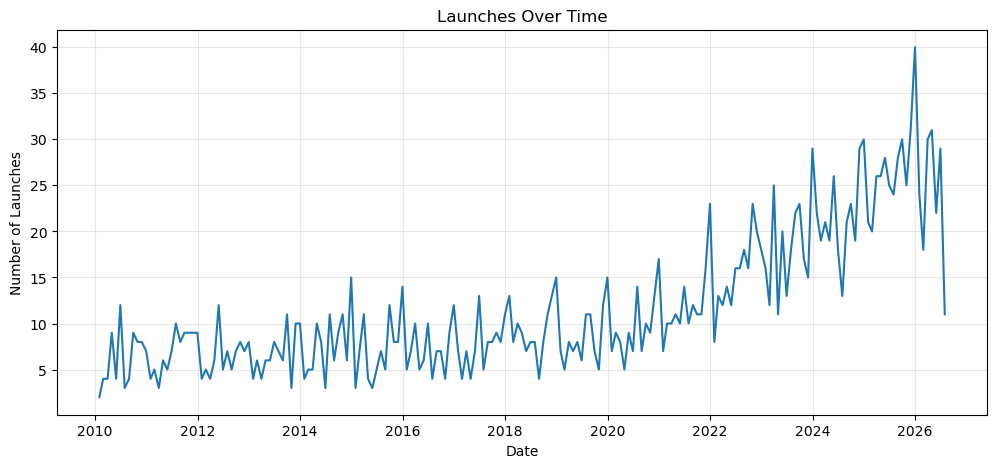

In [55]:
# Quick overview (full time analysis is found in time_series.ipynb)

launches_by_month = (
    launches_df.set_index('launch_datetime')
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(launches_by_month.index, launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

# That's really interesting?? Why does it spike so much in the end? Maybe confirm later with some other data for launches in 2026

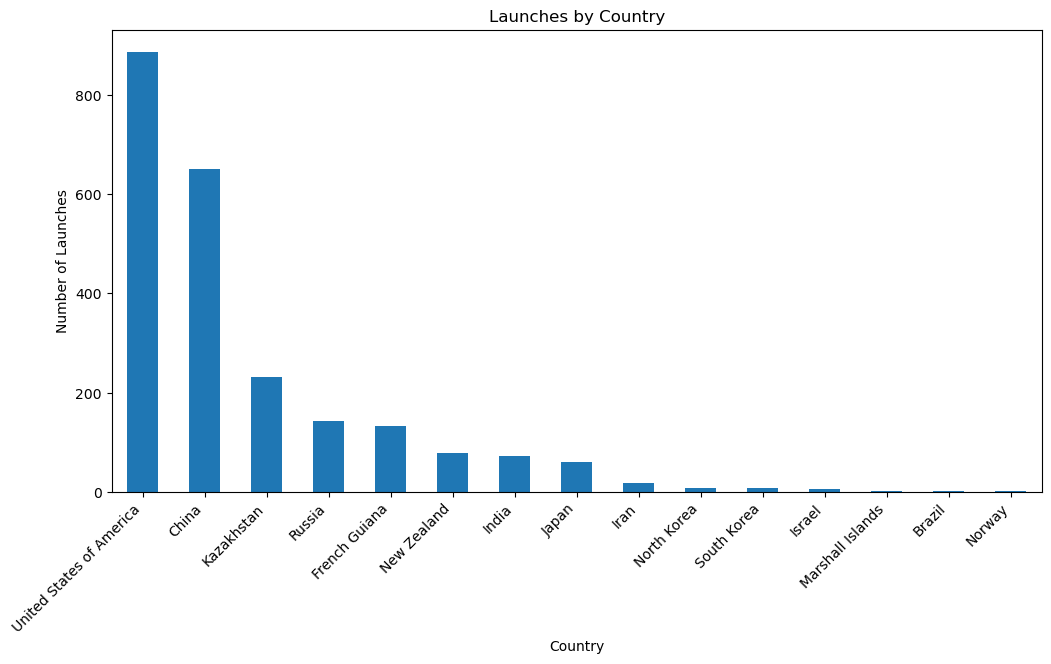

In [56]:
# Getting launches by country

launches_by_country = launches_df.groupby('launch_country').size().sort_values(ascending=False)
top_countries = launches_by_country.head(15)

plt.figure(figsize=(12, 6))

top_countries.plot(kind='bar')

plt.title("Launches by Country")
plt.xlabel('Country')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

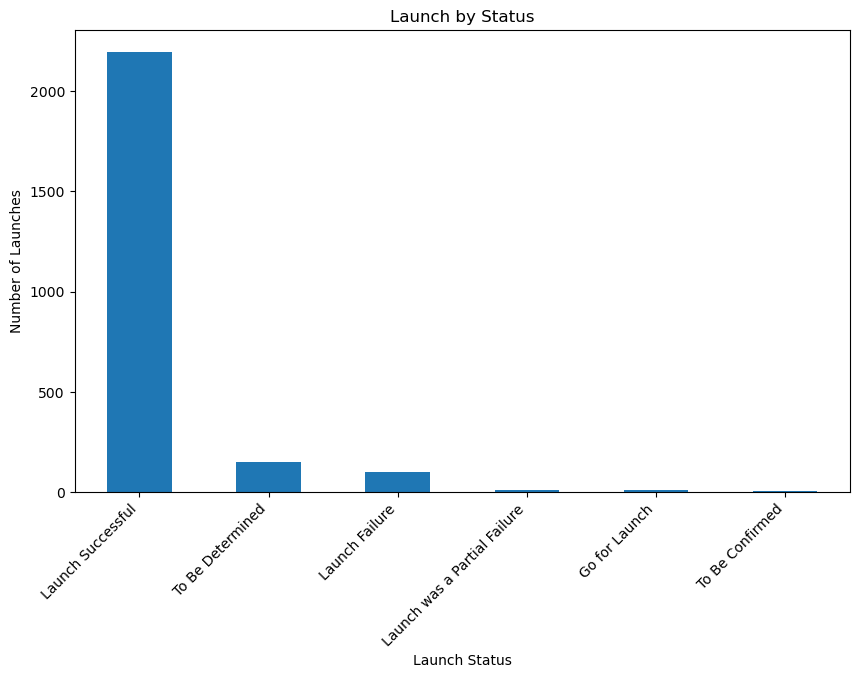

In [67]:
# Launches by status, this includes future/planned launches

launch_status = df.groupby('status').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

launch_status.plot(kind='bar')

plt.title('Launch by Status')
plt.xlabel('Launch Status')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45, ha='right')
plt.show()

In [34]:
# Want to do a check on the spike of 2026 launches found in the time series analysis

launches_2026 = df[df['year'] == 2026]

# Check for launches that haven't happened yet
launches_2026[launches_2026['month'] > 6]

# Check for launches with the "To Be Determined" status - 149 launches
future_launches = df[df['status'] == 'To Be Determined']
future_launches

# Check for month distribution of future_launches
future_launches.groupby('month').size().sort_values()

# As seen, there are 109 launches scheduled for December, a dispraporionate amount to previous records

month
11      2
10      4
7       8
8       9
9      17
12    109
dtype: int64

In [35]:
future_launches

,launch_id,launch_name,launch_designator,launch_datetime,launch_window_end,launch_window_start,failure_reason,status,status_abbrev,launch_provider,...,orbit,orbit_abbrev,launch_pad,launch_location,launch_country,pad_latitude,pad_longitude,year,month,quarter
2317,aafe107e-46d8-420c-bcb9-192069d80893,Soyuz 2.1b | 16 x Rassvet-3,NaN,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,NaN,To Be Determined,TBD,Russian Federal Space Agency (ROSCOSMOS),...,Polar Orbit,PO,Unknown Pad,"Plesetsk Cosmodrome, Russian Federation",Russia,62.925556,40.577778,2026,7,3
2318,d8eb4b68-5307-4b3b-b585-5598958defc2,Gravity-1 | Unknown Payload,NaN,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,NaN,To Be Determined,TBD,Orienspace Technology,...,Unknown,NaN,Haiyang offshore launch location,Haiyang Oriental Spaceport,China,36.631333,121.198361,2026,7,3
2319,9e27a1ed-e81a-4918-b32b-0380cf3a9f8f,Mir | Demo Flight,NaN,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,NaN,To Be Determined,TBD,Agency for Defense Development,...,Low Earth Orbit,LEO,ADD Offshore launch platform,Sea Launch,South Korea,33.216667,126.366667,2026,7,3
2320,8b7e748c-6ed5-4681-a898-827b4a23b8d7,Electron | The Grain Goddess Provides (iQPS La...,NaN,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,NaN,To Be Determined,TBD,Rocket Lab,...,Low Earth Orbit,LEO,Rocket Lab Launch Complex 1A,"Rocket Lab Launch Complex 1, Mahia Peninsula, ...",New Zealand,-39.262833,177.864469,2026,7,3
2321,be8b4b0d-1989-48a5-a96d-e8e4d59ed8b3,Falcon 9 Block 5 | Globalstar 2-R Mission 1 (x 9),NaN,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-07-31 00:00:00+00:00,NaN,To Be Determined,TBD,SpaceX,...,Low Earth Orbit,LEO,Space Launch Complex 40,"Cape Canaveral SFS, FL, USA",United States of America,28.561941,-80.577357,2026,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2464,3a4dc969-d264-48a1-b113-bf69a798a5c4,H3-24 | Lunar Polar Exploration Mission (LUPEX),NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,Mitsubishi Heavy Industries,...,Lunar Orbit,LO,Yoshinobu Launch Complex LP-2,"Tanegashima Space Center, Japan",Japan,30.400938,130.975640,2026,12,4
2465,06201706-da6b-467e-83b2-ef2ff8596e05,Vulcan | USSF-23,NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,United Launch Alliance,...,Unknown,NaN,Space Launch Complex 41,"Cape Canaveral SFS, FL, USA",United States of America,28.583410,-80.583036,2026,12,4
2466,0c26b3d4-43e3-4c1a-8976-592ff319bc51,Falcon 9 Block 5 | Nova-C IM-3,NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,SpaceX,...,Lunar Orbit,LO,Unknown Pad,"Cape Canaveral SFS, FL, USA",United States of America,28.458000,-80.528000,2026,12,4
2467,317a2749-46be-45e3-93f7-fbaecba04ac6,Vulcan | SDA Tranche 1 Tracking Layer B,NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,United Launch Alliance,...,Polar Orbit,PO,Space Launch Complex 3E,"Vandenberg SFB, CA, USA",United States of America,34.640000,-120.589500,2026,12,4


In [29]:
# The amount of launches in 2026 are not extremely significant compared to other years,  there only seems to be a spike during December
# Note, these are all TO BE DETERMINED, none of these launches have happened yet

df.groupby('year').size()

year
2010     74
2011     84
2012     78
2013     81
2014     93
2015     87
2016     86
2017     91
2018    114
2019    102
2020    115
2021    145
2022    186
2023    221
2024    260
2025    324
2026    328
dtype: int64